In [38]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
import matplotlib.style
matplotlib.style.use("ggplot")

In [20]:
import nltk
nltk.download(["punkt"])

[nltk_data] Downloading package punkt to /home/fahmi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Base Data

In [76]:
df = pd.read_excel(f"../data/data-corpus-base.xlsx", sheet_name="BEIR Corpus").dropna()
df.head()

,Kode Doc,Kode Dokumen,Judul,Konten
0,doc1,b2044980-d3a0-4cf5-91b7-69cda3b7aafe,Wakil Dubes Walanda Gumbira Ningali Holland In...,bogor hotél institut (bhi) gawé bareng jeung f...
1,doc2,3fe1a195-5081-4855-95fa-cba5eff1cdcf,Warga Bogor Mapag Taun anyar Islam,bogor - datang ton anyar islam 1431-hijréh pap...
2,doc3,c121c9b4-a97a-4ba4-8f5e-5e58578b17ce,Warugan Lemah: Pola Lembur Urang Sunda Buhun,naskah warugan lemah kandelna ngan tilu lempir...
3,doc4,b87199ed-ca2f-4e2b-a323-23f3b387a9aa,Manfaat Olahraga Pikeun Kasehatan,anu ku urang tos terang olahraga teh penting p...
4,doc5,cc6a7052-6620-46cc-8704-9f54e3e99016,DINA JANDÉLA INDUNG,"méméh layung kubur panineungan dina jandéla, g..."


In [77]:
df.shape

(1582, 4)

## MS-MARCO Triplet

In [13]:
df_triplet = pd.read_json("../data/marco/triplet.jsonl", lines=True)
df_triplet.head()

,query,positive,negative
0,Naon tujuan festival budaya di Bogor?,Festival anu buka wakil duta besar walanda keu...,Sagala rupa budaya milik bangsa indonésé dihad...
1,Saha anu hadir dina festival budaya ieu?,"Wakil duta besar walanda, annemieke ruigrok ka...",Festival budaya ieu ngan gel sapoé.
2,Dupi masyarakat Walanda resep ka budaya Indoné...,Teu eutik warga walanda anu mikaresep seni bud...,Kuring gumbira aya di indonésé nu jalma saroméah.
3,Dimana lokasi festival budaya ieu dilaksanakeun?,"Festival ieu dilaksanakeun di hotél salak, jal...","Suni, anu ogé management assitant erasmus huis..."
4,Sabaraha lami festival budaya ieu dilaksanakan?,Festival budaya ieu ngan gel sapoé.,Lamun tempo sajarah mangsa ka tukang indonésé ...


In [14]:
df_triplet.shape

(7898, 3)

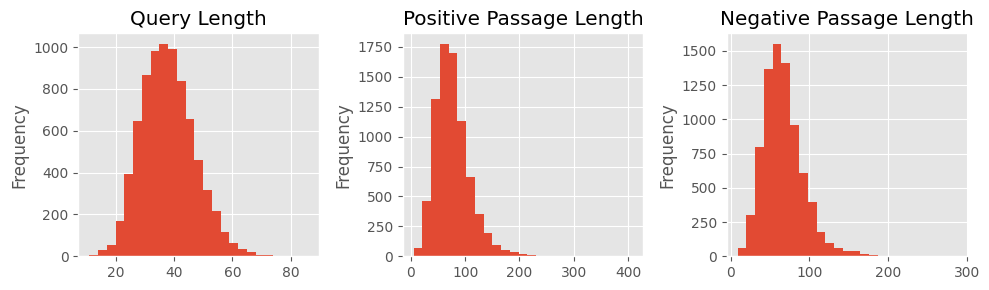

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
df_triplet["query"].str.len().plot.hist(bins=25, ax=ax[0])
ax[0].set_title("Query Length")

df_triplet["positive"].str.len().plot.hist(bins=25, ax=ax[1])
ax[1].set_title("Positive Passage Length")

df_triplet["negative"].str.len().plot.hist(bins=25, ax=ax[2])
ax[2].set_title("Negative Passage Length")

fig.tight_layout()
plt.show()

## BEIR

In [7]:
df_beir_corpus = pd.read_json("../data/beir/corpus.jsonl", lines=True)
df_beir_corpus.head()

,_id,title,text
0,b2044980-d3a0-4cf5-91b7-69cda3b7aafe,Wakil Dubes Walanda Gumbira Ningali Holland In...,bogor hotél institut (bhi) gawé bareng jeung f...
1,3fe1a195-5081-4855-95fa-cba5eff1cdcf,Warga Bogor Mapag Taun anyar Islam,bogor - datang ton anyar islam 1431-hijréh pap...
2,c121c9b4-a97a-4ba4-8f5e-5e58578b17ce,Warugan Lemah: Pola Lembur Urang Sunda Buhun,naskah warugan lemah kandelna ngan tilu lempir...
3,b87199ed-ca2f-4e2b-a323-23f3b387a9aa,Manfaat Olahraga Pikeun Kasehatan,anu ku urang tos terang olahraga teh penting p...
4,cc6a7052-6620-46cc-8704-9f54e3e99016,DINA JANDÉLA INDUNG,"méméh layung kubur panineungan dina jandéla, g..."


In [11]:
df_beir_corpus.shape

(1582, 3)

In [8]:
df_beir_queries = pd.read_json("../data/beir/queries.jsonl", lines=True)
df_beir_queries.head()

,_id,text
0,b4487cc3-2cfe-45fc-9f49-c8c3dca9f851,Naon tujuan festival Holland Indonésé?
1,9d2c7441-adb2-4f14-bcac-e0e14c223e2f,Saha nu ngawakilan Duta Besar Walanda di festi...
2,db27319c-4e30-4fc0-83f8-bd8380b45bff,Dina mana lokasina Holland Indonésé Festival?
3,943cf13b-7168-4926-be0f-19c6b2f9d68a,Kapan festival Holland Indonésé diayakeun?
4,afd93298-948f-48b5-b3ac-ad879fde7f68,Seni budaya naon anu dipamerkeun di festival?


In [15]:
df_beir_queries.shape

(7910, 2)

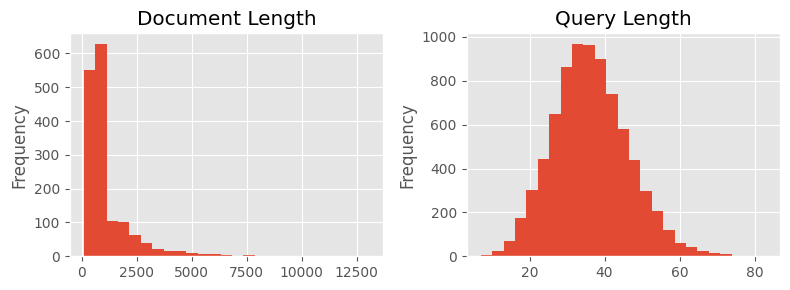

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
df_beir_corpus["text"].str.len().plot.hist(bins=25, ax=ax[0])
ax[0].set_title("Document Length")

df_beir_queries["text"].str.len().plot.hist(bins=25, ax=ax[1])
ax[1].set_title("Query Length")

fig.tight_layout()
plt.show()

In [10]:
df_beir_qrels = pd.read_csv("../data/beir/qrels.tsv", sep="\t")
df_beir_qrels.head()

,query-id,corpus-id,score
0,b4487cc3-2cfe-45fc-9f49-c8c3dca9f851,b2044980-d3a0-4cf5-91b7-69cda3b7aafe,1
1,9d2c7441-adb2-4f14-bcac-e0e14c223e2f,b2044980-d3a0-4cf5-91b7-69cda3b7aafe,1
2,db27319c-4e30-4fc0-83f8-bd8380b45bff,b2044980-d3a0-4cf5-91b7-69cda3b7aafe,1
3,943cf13b-7168-4926-be0f-19c6b2f9d68a,b2044980-d3a0-4cf5-91b7-69cda3b7aafe,1
4,afd93298-948f-48b5-b3ac-ad879fde7f68,b2044980-d3a0-4cf5-91b7-69cda3b7aafe,1


In [16]:
df_beir_qrels.shape

(7910, 3)

### Frequency Distribution

In [32]:
tokenizer = nltk.WhitespaceTokenizer()
tokens = [
    tokenizer.tokenize(
        s.lower(),
    )
    for s in df_beir_corpus["text"]
]

freq = nltk.FreqDist(itertools.chain(*tokens))
freq

FreqDist({'nu': 7601, 'ka': 3928, 'di': 3559, 'anu': 3558, 'ku': 3364, 'jeung': 3360, 'teu': 2816, 'dina': 2673, 'aya': 2166, 'atawa': 1838, ...})

In [41]:
freq_common = freq.most_common(20)
df_common = pd.Series([x[1] for x in freq_common], index=[x[0] for x in freq_common])
df_common

nu       7601
ka       3928
di       3559
anu      3558
ku       3364
jeung    3360
teu      2816
dina     2673
aya      2166
atawa    1838
ti       1750
téh      1664
geus     1536
tina     1405
jadi     1390
mah      1380
urang    1362
kana     1124
bisa     1124
keur      984
dtype: int64

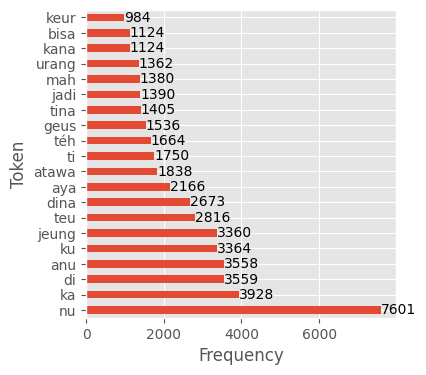

In [63]:
fig, ax = plt.subplots(figsize=(4, 4))
df_common.plot.barh(ax=ax)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Frequency")
ax.set_ylabel("Token")
plt.show()